# Project Overview
This project sets out to model the inflammatory dynamics over time in a system where either the system reverts to homeostasis or remains in a chronic, inflammatory state.


Inflammation resolution can be simplified as:
1. injury/trigger (S)
2. effector activity, inflammation (I)
3. tissue damage (D)
4. resolution (R)
5. repair/homeostasis (Q, dynamics of this parameter not included in this version)

The overall goal is to build a model that I can use to simulate different conditions that influence chronic inflammation and which simulations lead to homeostasis.

Overall model ideaology: Chronic inflammation emerges when positive feedback between inflammatory activity and tissue damage overwhelms regulatory suppresion or repair.

Version 0.0.1 - basic ODE modeling, assuming linear behavior.

Equations:

Equation 1: $$dI/dt = k_aS + k_{DI}D -k_{RI}RI-k_II$$

Equation 2: $$dD/dt = k_{ID}I-k_QD$$

Equation 3: $$dR/dt = k_{IR}I - k_RR$$


where:\
$k_aS$ = inflammatiory activation\
$k_{ID}D$ = damaged tissue feeding inflammation\
$k_{RI}RI$ = inflammation supression\
$k_II$ = natural decay of suppression\
$k_{ID}I$ = inflammation causing tissue injury\
$k_QD$ = damaged tissue being repaired\
$k_{IR}I$ = inflammation inducing inflammatory regulation\
$k_RR$ = regulatory signaling changing over time

In [ ]:
# installs
!pip install -q numpy scipy matplotlib pandas

In [ ]:
# imports
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# initial parameter values (chosen completely at random)
params = {
    "k_a": 0.5,
    "k_di": 0.2,
    "k_ri": 0.3,
    "k_i": 0.1,
    "k_id": 0.2,
    "k_q": 0.5,
    "k_ir": 0.2,
    "k_r": 0.1
}

### Note
Making the trigger (S) a function of time so that I can later investigate how the length of the trigger influences the overall model (units = hours)

# Model Setup


In [ ]:
# model function
def inflammation_model(t, y, params):
  I, D, R = y

  k_a = params["k_a"]
  k_di = params["k_di"]
  k_ri = params["k_ri"]
  k_i = params["k_i"]
  k_id = params["k_id"]
  k_q = params["k_q"]
  k_ir = params["k_ir"]
  k_r = params["k_r"]

  # trigger (acute inflammation)
  S = 1 if t < 5 else 0

  # eq1
  dI_dt = (k_a * S) + (k_di * D) - (k_ri * R * I) - (k_i * I)

  #eq2
  dD_dt = (k_id * I) - (k_q * D)

  #eq3
  dR_dt = (k_ir * I) - (k_r * R)

  return [dI_dt, dD_dt, dR_dt]

## Test 1: Healthy baseline model
After inital trigger, get the model to return to baseline and determine how long this takes.

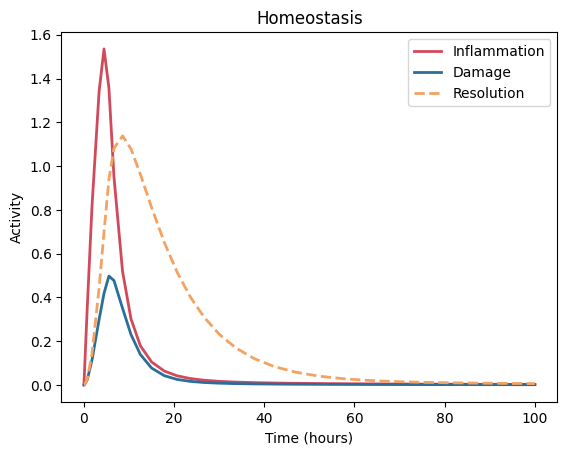

In [ ]:
solution = solve_ivp(
    inflammation_model,
    t_span=(0, 100),
    y0=[0, 0, 0],
    args=(params,)
)

plt.plot(solution.t,
         solution.y[0],
         label="Inflammation",
         color = '#D1495B',
         linewidth = 2)

plt.plot(solution.t,
         solution.y[1],
         label="Damage",
         color = '#2A6F97',
         linewidth = 2)

plt.plot(solution.t,
         solution.y[2],
         label="Resolution",
         color = "#F4A261",
         linestyle="--",
         linewidth = 2)

plt.xlabel("Time (hours)")
plt.ylabel("Activity")
plt.title("Homeostasis")
plt.legend()
plt.show()




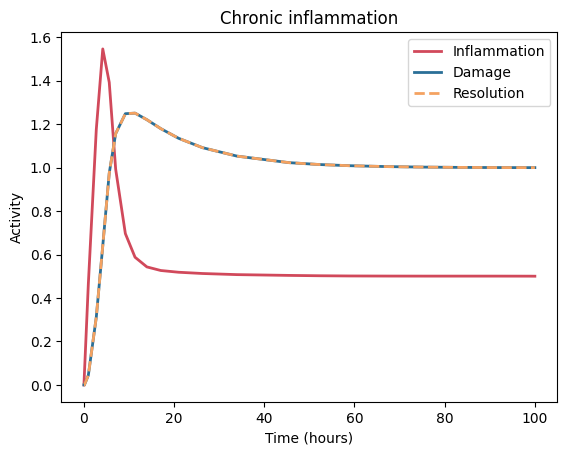

In [ ]:
# Chronic inflammation
params_chronic = {
    "k_a": 0.5,
    "k_di": 0.2,
    "k_ri": 0.3,
    "k_i": 0.1,
    "k_id": 0.2,
    "k_q": 0.1,
    "k_ir": 0.2,
    "k_r": 0.1
}

solution = solve_ivp(
    inflammation_model,
    t_span=(0, 100),
    y0=[0, 0, 0],
    args=(params_chronic,)
)

plt.plot(solution.t,
         solution.y[0],
         label="Inflammation",
         color = '#D1495B',
         linewidth = 2)

plt.plot(solution.t,
         solution.y[1],
         label="Damage",
         color = '#2A6F97',
         linewidth = 2)

plt.plot(solution.t,
         solution.y[2],
         label="Resolution",
         color = "#F4A261",
         linestyle="--",
         linewidth = 2)

plt.xlabel("Time (hours)")
plt.ylabel("Activity")
plt.title("Chronic inflammation")
plt.legend()
plt.show()

### Results
In this minimal model, chronicity is not an all-or-none event. Increasing repair capacity progressively reduces damage persistence and inflammatory duration until the system can return to baseline.

## Test 2

**Question**: Can stronger anti-inflammatory signaling rescue the system even when tissue repair is weak?

**Prediction**: Increasing $k_{ri}$ should decrease inflammatory severity and tissue damage and accelerate return toward homeostasis. The effect on $R$ is uncertain because stronger suppression may reduce the inflammatory signal that drives resolution activation.

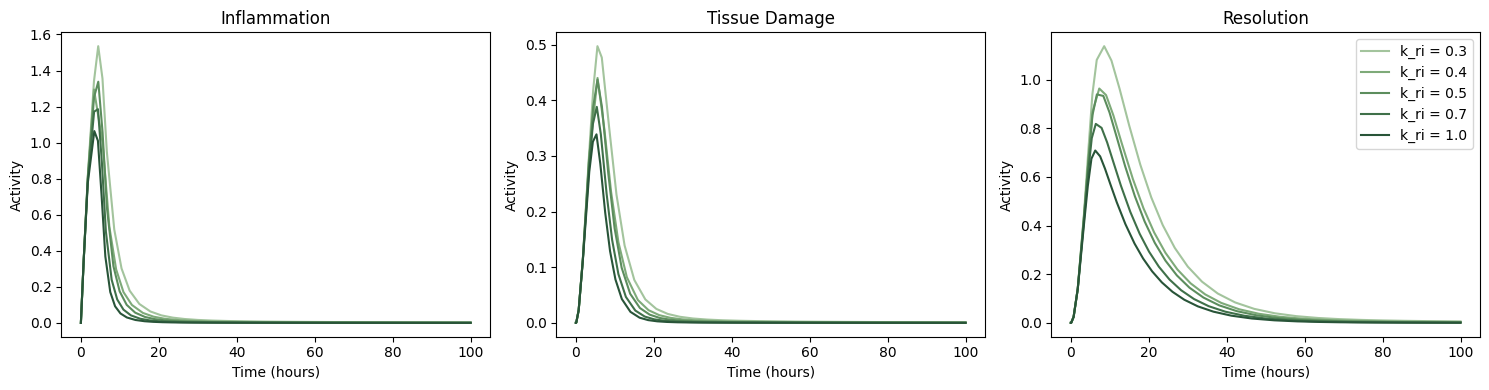

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

k_ri_values = [0.3, 0.4, 0.5, 0.7, 1.0]

colors = [
    "#A3C49D",
    "#7EAA79",
    "#5C8D5D",
    "#3F7049",
    "#285438"
]

for value, color in zip(k_ri_values, colors):

    params_test = params.copy()
    params_test["k_ri"] = value

    solution = solve_ivp(
        inflammation_model,
        t_span=(0, 100),
        y0=[0, 0, 0],
        args=(params_test,)
    )

    # Inflammation
    axes[0].plot(
        solution.t,
        solution.y[0],
        color = color,
        label=f"k_ri = {value}"
    )

    # Damage
    axes[1].plot(
        solution.t,
        solution.y[1],
        color = color,
        label=f"k_ri = {value}"
    )

    # Resolution
    axes[2].plot(
        solution.t,
        solution.y[2],
        color = color,
        label=f"k_ri = {value}"
    )


axes[0].set_title("Inflammation")
axes[1].set_title("Tissue Damage")
axes[2].set_title("Resolution")

for ax in axes:
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Activity")

axes[2].legend()


plt.tight_layout()
plt.show()

## Test 3

**Question**: How strongly/quickly does inflammation induce the resolution response?

**Prediction**: Increasing $k_{ir}$ should produce earlier/stronger resolution signaling, which should decrease inflammatory duration and tissue damage. The effect on the maximum resolution amplitude is uncertain because faster resolution induction also removes the inflammatory signal driving resolution.


**Note:** This iteration does not account for delay between inflammation and resolution.

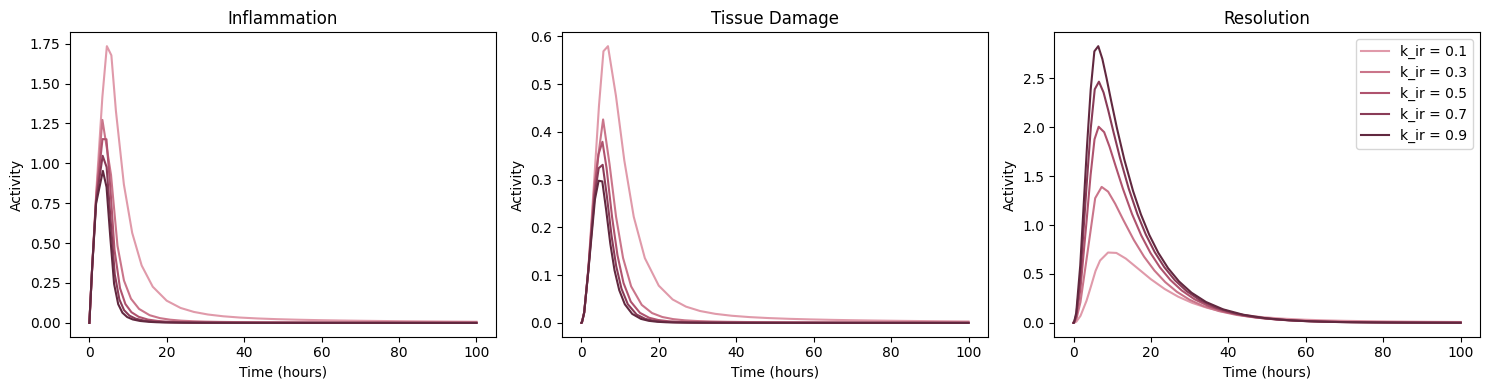

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

k_ir_values = [0.1, 0.3, 0.5, 0.7, 0.9]

colors = [
    "#E09AAA",
    "#CA758A",
    "#AF536E",
    "#893B57",
    "#61283F"
]

for value, color in zip(k_ir_values, colors):

    params_test = params.copy()
    params_test["k_ir"] = value

    solution = solve_ivp(
        inflammation_model,
        t_span=(0, 100),
        y0=[0, 0, 0],
        args=(params_test,)
    )

    # Inflammation
    axes[0].plot(
        solution.t,
        solution.y[0],
        color = color,
        label=f"k_ir = {value}"
    )

    # Damage
    axes[1].plot(
        solution.t,
        solution.y[1],
        color = color,
        label=f"k_ir = {value}"
    )

    # Resolution
    axes[2].plot(
        solution.t,
        solution.y[2],
        color = color,
        label=f"k_ir = {value}"
    )


axes[0].set_title("Inflammation")
axes[1].set_title("Tissue Damage")
axes[2].set_title("Resolution")

for ax in axes:
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Activity")

axes[2].legend()


plt.tight_layout()
plt.show()

# Sensitivity Analysis

**Question:** Which parameters influence the output of the system?

For this, there will be 2 outputs.

1. The AUC of inflammation -- this represents total immune abundance.
2. Time to resolution.

The second outcome is very important in this model because while inflammation can be resolved, that doesn't mean that tissue damage has not occurred. This analysis will feed into a more robust analysis on tissue damage later.

In [ ]:
# parameters
I_threshold = 0.05

In [ ]:
# outcome setup
def inflamm_auc(solution):
    I = solution.y[0]
    t = solution.t

    return np.trapezoid(I, t)


def t_to_res(solution, threshold=0.05):
    I = solution.y[0]
    t = solution.t

    peak_index = np.argmax(I)

    for i in range(peak_index, len(I)):
        if I[i] <= threshold and np.all(I[i:] <= threshold):
            return t[i]

    return np.nan

In [ ]:
t_eval = np.linspace(0, 100, 1001)

solution = solve_ivp(
    inflammation_model,
    t_span=(0, 100),
    y0=[0, 0, 0],
    t_eval=t_eval,
    args=(params,)
)

multipliers = [0.5, 0.75, 1.0, 1.25, 1.5]

results = []

for parameter in params.keys():

    baseline_value = params[parameter]

    for multiplier in multipliers:

        params_test = params.copy()
        params_test[parameter] = baseline_value * multiplier

        solution = solve_ivp(
            inflammation_model,
            t_span=(0, 100),
            y0=[0, 0, 0],
            t_eval=t_eval,
            args=(params_test,)
        )

        results.append({
            "parameter": parameter,
            "multiplier": multiplier,
            "value": params_test[parameter],
            "auc": inflamm_auc(solution),
            "resolution_time": t_to_res(solution)
        })


results_df = pd.DataFrame(results)

In [ ]:
results_df

,parameter,multiplier,value,auc,resolution_time
0,k_a,0.50,0.250,8.363242,23.0
1,k_a,0.75,0.375,9.777099,20.9
2,k_a,1.00,0.500,10.946065,19.4
3,k_a,1.25,0.625,11.400096,18.5
4,k_a,1.50,0.750,12.286196,17.6
5,k_di,0.50,0.100,9.203139,16.5
6,k_di,0.75,0.150,9.733524,17.9
7,k_di,1.00,0.200,10.946065,19.4
8,k_di,1.25,0.250,12.041549,21.3
9,k_di,1.50,0.300,13.445578,23.7


In [ ]:
param_colors = {
    "k_a":  "#1496B8",
    "k_di": "#FFB000",
    "k_ri": "#149678",
    "k_i":  "#D01C24",
    "k_id": "#6940AD",
    "k_q":  "#E6550D",
    "k_ir": "#D01C7F",
    "k_r":  "#264E5C",
}

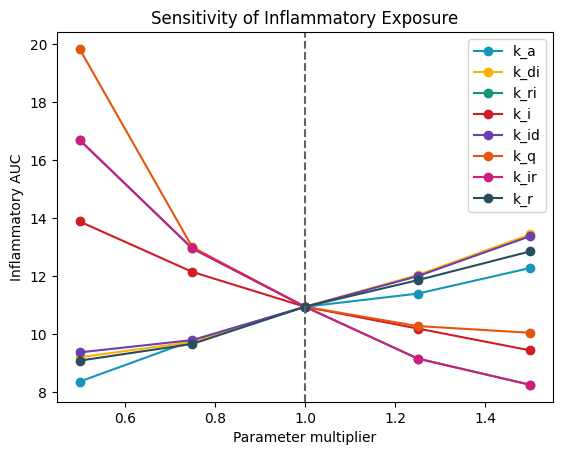

In [ ]:
for parameter in results_df["parameter"].unique():

    subset = results_df[
        results_df["parameter"] == parameter
    ]

    plt.plot(
        subset["multiplier"],
        subset["auc"],
        marker="o",
        color=param_colors[parameter],
        label=parameter
    )

plt.axvline(1,
            linestyle="--",
            color="#636363")

plt.xlabel("Parameter multiplier")
plt.ylabel("Inflammatory AUC")
plt.title("Sensitivity of Inflammatory Exposure")
plt.legend()
plt.show()

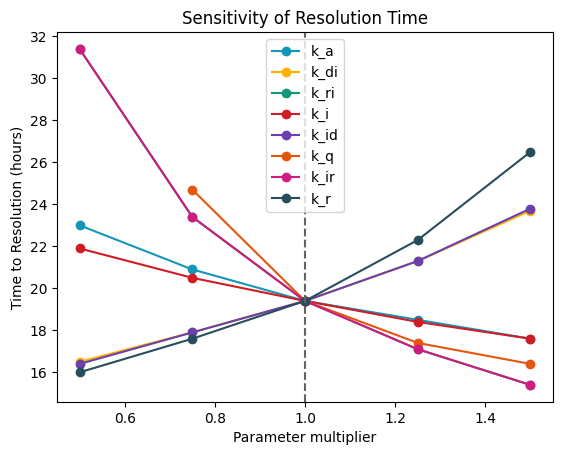

In [ ]:
for parameter in results_df["parameter"].unique():

    subset = results_df[
        results_df["parameter"] == parameter
    ]

    plt.plot(
        subset["multiplier"],
        subset["resolution_time"],
        marker= "o",
        color=param_colors[parameter],
        label=parameter
    )

plt.axvline(1,
            linestyle="--",
            color="#636363")

plt.xlabel("Parameter multiplier")
plt.ylabel("Time to Resolution (hours)")
plt.title("Sensitivity of Resolution Time")
plt.legend()
plt.show()

Updated hypothesis with this information:

Inflammatory outcome emerges from competition between damage-amplifying positive feedback, resolution-mediated negative feedback, and tissue repair. These mechanisms independently shape inflammatory burden and duration.

# Competition

Previous analysis compared how each parameter of the model effected the outcomes. This analysis will focus on the competition between multiple parameters. For example, can high repair signals overcome strong inflammation?

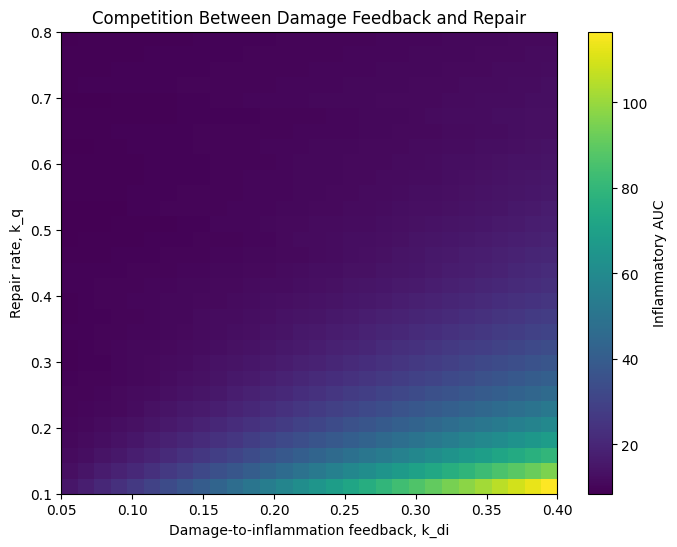

In [ ]:
# How much repair capacity is needed to counteract damage-driven inflammatory feedback?

k_q_values = np.linspace(0.1, 0.8, 30)
k_di_values = np.linspace(0.05, 0.4, 30)

results_2d = []

for k_q in k_q_values:
    for k_di in k_di_values:

        params_test = params.copy()
        params_test["k_q"] = k_q
        params_test["k_di"] = k_di

        solution = solve_ivp(
            inflammation_model,
            t_span=(0, 100),
            y0=[0, 0, 0],
            t_eval=t_eval,
            args=(params_test,)
        )

        results_2d.append({
            "k_q": k_q,
            "k_di": k_di,
            "auc": inflamm_auc(solution),
            "resolution_time": t_to_res(solution)
        })


results_2d_df = pd.DataFrame(results_2d)

pivot_auc = results_2d_df.pivot(
    index="k_q",
    columns="k_di",
    values="auc"
)

plt.figure(figsize=(8, 6))

plt.imshow(
    pivot_auc.values,
    origin="lower",
    aspect="auto",
    extent=[
        k_di_values.min(),
        k_di_values.max(),
        k_q_values.min(),
        k_q_values.max()
    ]
)

plt.colorbar(label="Inflammatory AUC")
plt.xlabel("Damage-to-inflammation feedback, k_di")
plt.ylabel("Repair rate, k_q")
plt.title("Competition Between Damage Feedback and Repair")

plt.show()

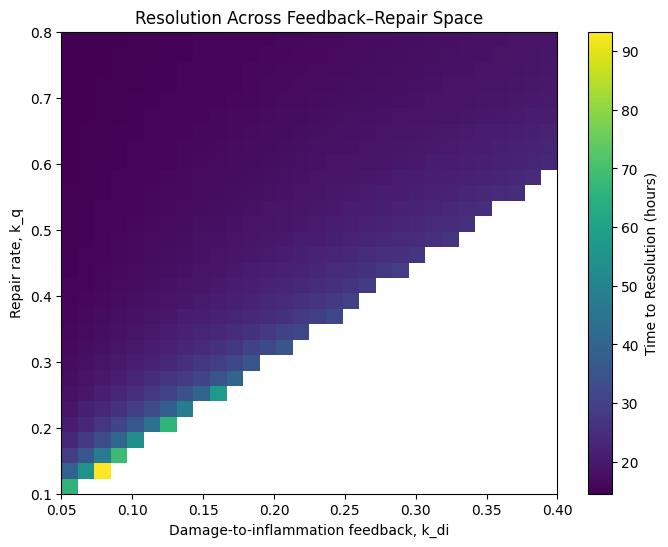

In [ ]:
pivot_res = results_2d_df.pivot(
    index="k_q",
    columns="k_di",
    values="resolution_time"
)

plt.figure(figsize=(8, 6))

plt.imshow(
    pivot_res.values,
    origin="lower",
    aspect="auto",
    extent=[
        k_di_values.min(),
        k_di_values.max(),
        k_q_values.min(),
        k_q_values.max()
    ]
)

plt.colorbar(label="Time to Resolution (hours)")
plt.xlabel("Damage-to-inflammation feedback, k_di")
plt.ylabel("Repair rate, k_q")
plt.title("Resolution Across Feedback–Repair Space")

plt.show()